# Relevance Classification — Direct LLM Approach

Single LLM call that extracts features and outputs a relevance verdict with brief reasoning.

Primary target: `MC_relevance_modifiers` (paper-faithful mechanistic label).
Diagnostic only: `dataset_relevance`, retained as `human_relevance` for comparison.

In [1]:
import os
os.chdir(r"C:\Users\beav3503\dev\llm_metadata")
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore")

import json
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Literal, Optional
from pydantic import Field
from joblib import Memory
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

from llm_metadata.schemas.fuster_features import DatasetFeaturesExtraction
from llm_metadata.openai_io import get_openai_client
from llm_metadata.gpt_extract import _response_usage_cost, MODEL_COST_PER_1M_TOKENS

## Extended Schema (local definition — no src changes)

In [2]:
class DatasetFeaturesWithRelevance(DatasetFeaturesExtraction):
    has_dataset: bool = Field(
        description="True if the record describes an actual dataset produced or curated by the authors."
    )
    relevance: Literal["H", "M", "L", "X"] = Field(
        description=(
            "Overall dataset relevance for Quebec biodiversity monitoring. "
            "H=High, M=Moderate, L=Low, X=Non-relevant or no dataset."
        )
    )
    relevance_reasoning: str = Field(
        description="1-3 sentences explaining the relevance verdict based on data type, temporal/spatial extent, and modulators."
    )

print("Schema fields:")
for name, field_info in DatasetFeaturesWithRelevance.model_fields.items():
    if name in ("has_dataset", "relevance", "relevance_reasoning"):
        print(f"  + {name}: {field_info.description[:60]}...")

Schema fields:
  + has_dataset: True if the record describes an actual dataset produced or c...
  + relevance: Overall dataset relevance for Quebec biodiversity monitoring...
  + relevance_reasoning: 1-3 sentences explaining the relevance verdict based on data...


## Prompt with Relevance Block

Extends the existing abstract prompt with a paper-faithful mechanistic relevance block.
The prompt hash is included in the cache key so prompt edits invalidate stale notebook caches.

In [3]:
from llm_metadata.prompts.abstract import SYSTEM_MESSAGE as BASE_SYSTEM_MESSAGE

RELEVANCE_BLOCK = """## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using the same mechanistic target used in WU-R1 (`MC_relevance_modifiers`).
Prefer conservative scores when evidence is incomplete.

Main Classifiers (majority vote):
- Data type: H=abundance, density, EBV genetic analysis; M=distribution, presence-absence; L=presence-only, relative abundance, species richness, non-EBV genetic analysis; X=no species or biodiversity data
- Temporal extent: H=12+ years, M=3-11 years, L=1-2 years, X=not stated
- Spatial extent: H=>15000 km², M=5000-15000 km², L=<5000 km², X=not stated

If there is no majority:
- Special case: if data type is H and temporal or spatial is X, return L
- Otherwise return the lower of data type and the better of temporal/spatial

Modulators:
- Upgrade by one level if any of these are explicitly supported: multispecies (>10 species), threatened_species, new_species_science, new_species_region, bias_north_south
- Set has_dataset=False and relevance=\"X\" if no primary dataset is described."""

SYSTEM_MESSAGE_WITH_RELEVANCE = BASE_SYSTEM_MESSAGE + "\n\n" + RELEVANCE_BLOCK
PROMPT_HASH = hashlib.md5(SYSTEM_MESSAGE_WITH_RELEVANCE.encode()).hexdigest()[:8]

print("System message length:", len(SYSTEM_MESSAGE_WITH_RELEVANCE))
print("Prompt hash:", PROMPT_HASH)
print("\nRelevance block appended:\n")
print(RELEVANCE_BLOCK[:500])

System message length: 4764
Prompt hash: a86ef443

Relevance block appended:

## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using the same mechanistic target used in WU-R1 (`MC_relevance_modifiers`).
Prefer conservative scores when evidence is incomplete.

Main Classifiers (majority vote):
- Data type: H=abundance, density, EBV genetic analysis; M=distribution, presence-absence; L=presence-only, relative abundance, species richness, non-EBV genetic analysis; X=no species or biodiversity data
- Tem


## Data Loading & GT Preparation

Primary evaluation target: `MC_relevance_modifiers`.
Keep spreadsheet `dataset_relevance` as `human_relevance` for diagnostic comparison only.

In [4]:
manifest = pd.read_csv("data/manifests/dev_subset_data_paper.csv")
raw = pd.read_excel("data/dataset_092624.xlsx")

subset_ids = manifest["gt_record_id"].astype(int)
df = raw[raw["id"].isin(subset_ids)].copy()

# Preserve the spreadsheet label separately for diagnostics.
df["human_relevance"] = (
    df["dataset_relevance"]
    .replace({"No dataset": "X", " X": "X"})
    .fillna("")
    .astype(str)
    .str.strip()
)

# Primary paper-faithful target for this notebook.
df["gt_relevance"] = df["MC_relevance_modifiers"].fillna("").astype(str).str.strip()

# Merge manifest text so the notebook uses the same description text as abstract mode.
df_merged = df.merge(
    manifest[["gt_record_id", "abstract"]].rename(columns={"abstract": "full_text_manifest"}),
    left_on="id",
    right_on="gt_record_id",
    how="left",
)

if "full_text" in df_merged.columns:
    df_merged["input_text"] = df_merged["full_text"].fillna(df_merged.get("full_text_manifest", ""))
else:
    df_merged["input_text"] = df_merged.get("full_text_manifest", df_merged.get("abstract", ""))

eval_df = df_merged[df_merged["gt_relevance"].isin(["H", "M", "L", "X"])].copy()

print(f"Evaluation records (mechanistic target): {len(eval_df)}")
print("\nPrimary target distribution (MC_relevance_modifiers):")
print(eval_df["gt_relevance"].value_counts())
print("\nDiagnostic human-label distribution (dataset_relevance collapsed):")
print(eval_df["human_relevance"].value_counts())

Evaluation records (mechanistic target): 30

Primary target distribution (MC_relevance_modifiers):
gt_relevance
M    12
H    10
L     8
Name: count, dtype: int64

Diagnostic human-label distribution (dataset_relevance collapsed):
human_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64


## LLM Extraction with Caching

Loop over the 30 dev-subset records, calling `client.responses.parse()` directly with
`DatasetFeaturesWithRelevance` when OpenAI credentials are available.

If credentials are missing, the notebook falls back to the existing
`notebooks/results/relevance_llm_direct_predictions.csv` file so the aligned target metrics
and comparison artifacts can still be refreshed without new API calls.

In [5]:
MODEL = "gpt-5-mini"
REASONING = {"effort": "low"}
MAX_OUTPUT_TOKENS = 4096

CACHE_DIR = Path("cache/relevance_llm_direct")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
memory = Memory(str(CACHE_DIR), verbose=0)

SCHEMA_HASH = hashlib.md5(
    json.dumps(DatasetFeaturesWithRelevance.model_json_schema(), sort_keys=True).encode()
).hexdigest()[:8]

print(f"Model: {MODEL}")
print(f"Schema hash: {SCHEMA_HASH}")
print(f"Prompt hash: {PROMPT_HASH}")
print(f"Cache dir: {CACHE_DIR}")


def extract_record(record_id: str, text: str) -> dict:
    """Extract features + relevance for one record, with joblib caching."""
    text_hash = hashlib.md5(text.encode()).hexdigest()[:8]
    cache_key = f"{record_id}|{MODEL}|{SCHEMA_HASH}|{PROMPT_HASH}|{text_hash}"

    @memory.cache
    def _call(ck: str) -> dict:
        del ck
        client = get_openai_client()
        response = client.responses.parse(
            model=MODEL,
            input=[
                {"role": "system", "content": SYSTEM_MESSAGE_WITH_RELEVANCE},
                {"role": "user", "content": text},
            ],
            text_format=DatasetFeaturesWithRelevance,
            reasoning=REASONING,
            max_output_tokens=MAX_OUTPUT_TOKENS,
        )
        return response.model_dump()

    return _call(cache_key)

print("Extraction function ready.")

Model: gpt-5-mini
Schema hash: 152e9399
Prompt hash: a86ef443
Cache dir: cache\relevance_llm_direct
Extraction function ready.


In [6]:
SAVED_PREDICTIONS_PATH = Path("notebooks/results/relevance_llm_direct_predictions.csv")
can_call_api = bool(os.getenv("OPENAI_API_KEY"))
prediction_source = "fresh_api_calls" if can_call_api else "saved_predictions_fallback"

valid_records = eval_df[eval_df["input_text"].notna() & (eval_df["input_text"].str.len() > 50)].copy()
print(f"Records with text: {len(valid_records)}")
print(f"Prediction source: {prediction_source}")

results = []
total_cost = 0.0

if can_call_api:
    for i, (_, row) in enumerate(valid_records.iterrows()):
        record_id = str(row["id"])
        text = str(row["input_text"])

        try:
            response_dict = extract_record(record_id, text)

            from openai.types.responses.parsed_response import ParsedResponse
            response = ParsedResponse[DatasetFeaturesWithRelevance].model_construct(**response_dict)
            output = response.output_parsed

            cost_info = _response_usage_cost(response_dict["usage"], model=MODEL) if response_dict.get("usage") else {}
            run_cost = cost_info.get("total_cost", 0)
            total_cost += run_cost

            results.append({
                "id": row["id"],
                "gt_relevance": row["gt_relevance"],
                "human_relevance": row["human_relevance"],
                "pred_relevance": output.relevance if output else None,
                "has_dataset": output.has_dataset if output else None,
                "relevance_reasoning": output.relevance_reasoning if output else None,
                "data_type": output.data_type if output else None,
                "temp_range_i": output.temp_range_i if output else None,
                "temp_range_f": output.temp_range_f if output else None,
                "spatial_range_km2": output.spatial_range_km2 if output else None,
                "cost": run_cost,
                "status": "ok",
            })

            if (i + 1) % 10 == 0:
                print(f"  [{i+1}/{len(valid_records)}] ${total_cost:.4f} total so far")

        except Exception as e:
            print(f"  ERROR record {record_id}: {e}")
            results.append({
                "id": row["id"],
                "gt_relevance": row["gt_relevance"],
                "human_relevance": row["human_relevance"],
                "pred_relevance": None,
                "status": "error",
                "error": str(e),
            })
else:
    if not SAVED_PREDICTIONS_PATH.exists():
        raise RuntimeError(
            "OPENAI_API_KEY is not set and no saved predictions file exists at "
            f"{SAVED_PREDICTIONS_PATH}"
        )
    print("OPENAI_API_KEY not set; loading saved direct-LLM predictions instead of issuing new API calls.")
    saved_predictions = pd.read_csv(SAVED_PREDICTIONS_PATH)
    saved_predictions = saved_predictions.drop(columns=["gt_relevance", "human_relevance"], errors="ignore")
    merged_predictions = valid_records[["id", "gt_relevance", "human_relevance"]].merge(
        saved_predictions,
        on="id",
        how="left",
    )
    if "cost" in merged_predictions.columns:
        total_cost = float(merged_predictions["cost"].fillna(0).sum())
    results = merged_predictions.to_dict(orient="records")

print(f"\nDone. Total cost: ${total_cost:.4f}")
print(f"Success: {sum(1 for r in results if pd.notna(r.get('pred_relevance')))}")
print(f"Errors:  {sum(1 for r in results if r.get('status') == 'error')}")

Records with text: 30
Prediction source: saved_predictions_fallback
OPENAI_API_KEY not set; loading saved direct-LLM predictions instead of issuing new API calls.



Done. Total cost: $0.0909
Success: 30
Errors:  0


In [7]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df["pred_relevance"].notna()].copy()

print(f"Records with predictions: {len(results_df)}")
print("\nPredicted relevance distribution:")
print(results_df["pred_relevance"].value_counts())
print("\nGT / human / predicted sample:")
sample_cols = [
    "id",
    "gt_relevance",
    "human_relevance",
    "pred_relevance",
    "has_dataset",
    "data_type",
    "temp_range_i",
    "temp_range_f",
]
sample_cols = [col for col in sample_cols if col in results_df.columns]
results_df[sample_cols].head(8) if sample_cols else results_df.head(8)

Records with predictions: 30

Predicted relevance distribution:
pred_relevance
M    14
H     8
X     6
L     2
Name: count, dtype: int64

GT / human / predicted sample:


,id,gt_relevance,human_relevance,pred_relevance,has_dataset,data_type,temp_range_i,temp_range_f
0,5,M,M,M,True,['genetic_analysis'],2006.0,2007.0
1,9,L,L,M,True,['abundance'],NaN,NaN
2,11,M,M,M,True,"['traits', 'time_series', 'distribution', 'oth...",1999.0,2011.0
3,12,H,M,H,True,['other'],2004.0,2011.0
4,19,M,M,M,True,['genetic_analysis'],2011.0,2014.0
5,24,H,H,X,True,['genetic_analysis'],NaN,NaN
6,27,M,M,H,True,['genetic_analysis'],2010.0,2014.0
7,29,H,H,H,True,"['abundance', 'distribution']",NaN,NaN


## Evaluation Metrics

Primary metrics are computed against `MC_relevance_modifiers`.
A second diagnostic block compares the same predictions against `human_relevance`.

In [8]:
labels = ["H", "M", "L", "X"]

y_true = results_df["gt_relevance"]
y_pred = results_df["pred_relevance"]
present_labels = [label for label in labels if label in set(y_true)]

print("=== WU-R2: Direct LLM vs Fuster MC+Modulators ===\n")
print("Target labels present in dev subset:", present_labels)
print(classification_report(y_true, y_pred, labels=present_labels, zero_division=0))

def binary_collapse(s):
    return "relevant" if s in ("H", "M") else "not_relevant"

y_true_bin = y_true.map(binary_collapse)
y_pred_bin = y_pred.map(binary_collapse)

p_r2 = precision_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
r_r2 = recall_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
f1_r2 = f1_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
macro_f1_r2 = f1_score(y_true, y_pred, labels=present_labels, average="macro", zero_division=0)
macro_f1_r2_all = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

print("\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_r2:.3f}  Recall: {r_r2:.3f}  F1: {f1_r2:.3f}")
print(f"\nMacro F1 over target-present labels: {macro_f1_r2:.3f}")
print(f"Macro F1 over all four labels:       {macro_f1_r2_all:.3f}")

human_true = results_df["human_relevance"]
human_present_labels = [label for label in labels if label in set(human_true)]
y_true_human_bin = human_true.map(binary_collapse)

p_r2_human = precision_score(y_true_human_bin, y_pred_bin, pos_label="relevant", zero_division=0)
r_r2_human = recall_score(y_true_human_bin, y_pred_bin, pos_label="relevant", zero_division=0)
f1_r2_human = f1_score(y_true_human_bin, y_pred_bin, pos_label="relevant", zero_division=0)
macro_f1_r2_human = f1_score(
    human_true,
    y_pred,
    labels=human_present_labels,
    average="macro",
    zero_division=0,
)

print("\n=== Diagnostic: same predictions vs human dataset_relevance ===\n")
print("Human-label target labels:", human_present_labels)
print(classification_report(human_true, y_pred, labels=human_present_labels, zero_division=0))
print("\nBinary (H+M=relevant vs L+X=not_relevant):")
print(f"  Precision: {p_r2_human:.3f}  Recall: {r_r2_human:.3f}  F1: {f1_r2_human:.3f}")
print(f"\nMacro F1 over human-label-present labels: {macro_f1_r2_human:.3f}")

=== WU-R2: Direct LLM vs Fuster MC+Modulators ===

Target labels present in dev subset: ['H', 'M', 'L']
              precision    recall  f1-score   support

           H       0.62      0.50      0.56        10
           M       0.50      0.58      0.54        12
           L       1.00      0.25      0.40         8

   micro avg       0.58      0.47      0.52        30
   macro avg       0.71      0.44      0.50        30
weighted avg       0.68      0.47      0.51        30


Binary (H+M=relevant vs L+X=not_relevant):
  Precision: 0.773  Recall: 0.773  F1: 0.773

Macro F1 over target-present labels: 0.498
Macro F1 over all four labels:       0.374

=== Diagnostic: same predictions vs human dataset_relevance ===

Human-label target labels: ['H', 'M', 'L', 'X']
              precision    recall  f1-score   support

           H       0.25      0.33      0.29         6
           M       0.43      0.50      0.46        12
           L       0.50      0.09      0.15        11
        

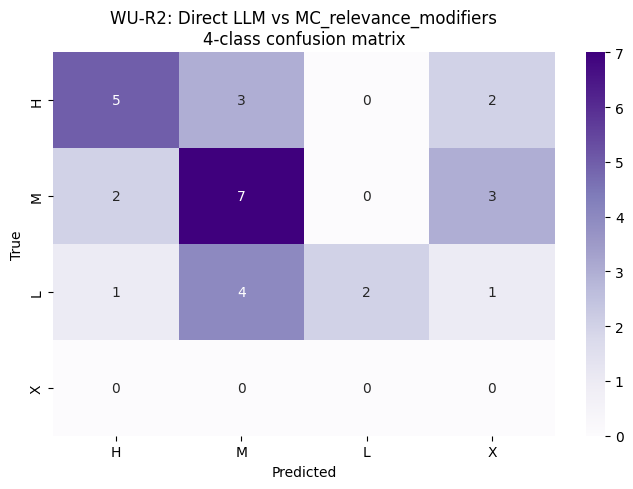

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Purples", ax=ax)
ax.set_title("WU-R2: Direct LLM vs MC_relevance_modifiers\n4-class confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("notebooks/results/relevance_llm_direct_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Mismatch Analysis

Spot-check `relevance_reasoning` on mismatches.

In [10]:
mismatches = results_df[results_df["gt_relevance"] != results_df["pred_relevance"]].copy()
print(f"Mismatches: {len(mismatches)}/{len(results_df)} ({len(mismatches)/len(results_df):.1%})")

for _, row in mismatches.iterrows():
    print(f"\n--- Record {row['id']} ---")
    print(f"  GT mechanistic: {row['gt_relevance']}  |  Human label: {row.get('human_relevance')}  |  Pred: {row['pred_relevance']}")
    print(f"  has_dataset: {row.get('has_dataset')}")
    print(f"  data_type: {row.get('data_type')}")
    print(f"  temporal: {row.get('temp_range_i')}–{row.get('temp_range_f')}")
    print(f"  spatial: {row.get('spatial_range_km2')} km²")
    reasoning = row.get("relevance_reasoning", "")
    if reasoning:
        print(f"  Reasoning: {reasoning[:200]}")

Mismatches: 16/30 (53.3%)

--- Record 9 ---
  GT mechanistic: L  |  Human label: L  |  Pred: M
  has_dataset: True
  data_type: ['abundance']
  temporal: nan–nan
  spatial: nan km²
  Reasoning: Primary dataset contains abundance data (high-value EBV type) from raccoon and skunk captures in Québec (Montérégie and Estrie) with spatial coordinates; however temporal and spatial extents are not r

--- Record 24 ---
  GT mechanistic: H  |  Human label: H  |  Pred: X
  has_dataset: True
  data_type: ['genetic_analysis']
  temporal: nan–nan
  spatial: nan km²
  Reasoning: The study produced primary genetic (microsatellite) data (high-value EBV data type), but the abstract does not report temporal extent or a spatial range in km²; with missing temporal and spatial infor

--- Record 27 ---
  GT mechanistic: M  |  Human label: M  |  Pred: H
  has_dataset: True
  data_type: ['genetic_analysis']
  temporal: 2010.0–2014.0
  spatial: nan km²
  Reasoning: Genetic dataset (microsatellite genotypes) dir

## Summary Comparison Table

This notebook appends the refreshed `R2` row to a combined comparison artifact written to
`notebooks/results/relevance_comparison_summary.csv`.

`R1-A`, `R1-B`, and the mechanistic-vs-human diagnostic rows are loaded from
`notebooks/results/relevance_mechanistic_summary.csv`.

In [11]:
results_dir = Path("notebooks/results")
results_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(results_dir / "relevance_llm_direct_predictions.csv", index=False)
print("Saved predictions: notebooks/results/relevance_llm_direct_predictions.csv")

summary = {
    "method": "R2: Direct LLM vs Fuster MC+Modulators",
    "model": MODEL,
    "target": "MC_relevance_modifiers",
    "diagnostic_target": "dataset_relevance",
    "prediction_source": prediction_source,
    "n_records": int(len(results_df)),
    "target_labels": present_labels,
    "macro_f1_present_labels": round(macro_f1_r2, 3),
    "macro_f1_all_labels": round(macro_f1_r2_all, 3),
    "binary_f1_relevant": round(f1_r2, 3),
    "binary_precision": round(p_r2, 3),
    "binary_recall": round(r_r2, 3),
    "diagnostic_vs_human": {
        "macro_f1_present_labels": round(macro_f1_r2_human, 3),
        "binary_f1_relevant": round(f1_r2_human, 3),
        "binary_precision": round(p_r2_human, 3),
        "binary_recall": round(r_r2_human, 3),
    },
    "prompt_hash_current": PROMPT_HASH,
    "schema_hash": SCHEMA_HASH,
    "total_cost_usd": round(total_cost, 4),
}
print("\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

with open(results_dir / "relevance_llm_direct_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print("\nSaved summary: notebooks/results/relevance_llm_direct_summary.json")

mechanistic_summary = pd.read_csv(results_dir / "relevance_mechanistic_summary.csv")
r2_row = pd.DataFrame([
    {
        "Method": "R2: Direct LLM vs Fuster MC+Modulators",
        "4-class macro F1": round(macro_f1_r2, 3),
        "Binary F1 (relevant)": round(f1_r2, 3),
        "Binary P": round(p_r2, 3),
        "Binary R": round(r_r2, 3),
    }
])
comparison_df = pd.concat(
    [
        mechanistic_summary[mechanistic_summary["Method"] != "R2: Direct LLM vs Fuster MC+Modulators"],
        r2_row,
    ],
    ignore_index=True,
)
order = [
    "R1-A: Rules on GT features vs Fuster MC+Modulators",
    "R1-B: Rules on LLM features vs Fuster MC+Modulators",
    "R2: Direct LLM vs Fuster MC+Modulators",
    "Diagnostic: Fuster MC+Modulators vs human dataset_relevance",
]
comparison_df["Method"] = pd.Categorical(comparison_df["Method"], categories=order, ordered=True)
comparison_df = comparison_df.sort_values("Method").reset_index(drop=True)
comparison_df.to_csv(results_dir / "relevance_comparison_summary.csv", index=False)
print("Saved comparison: notebooks/results/relevance_comparison_summary.csv")
comparison_df

Saved predictions: notebooks/results/relevance_llm_direct_predictions.csv

Summary:
  method: R2: Direct LLM vs Fuster MC+Modulators
  model: gpt-5-mini
  target: MC_relevance_modifiers
  diagnostic_target: dataset_relevance
  prediction_source: saved_predictions_fallback
  n_records: 30
  target_labels: ['H', 'M', 'L']
  macro_f1_present_labels: 0.498
  macro_f1_all_labels: 0.374
  binary_f1_relevant: 0.773
  binary_precision: 0.773
  binary_recall: 0.773
  diagnostic_vs_human: {'macro_f1_present_labels': 0.297, 'binary_f1_relevant': 0.75, 'binary_precision': 0.682, 'binary_recall': 0.833}
  prompt_hash_current: a86ef443
  schema_hash: 152e9399
  total_cost_usd: 0.0909

Saved summary: notebooks/results/relevance_llm_direct_summary.json
Saved comparison: notebooks/results/relevance_comparison_summary.csv


,Method,4-class macro F1,Binary F1 (relevant),Binary P,Binary R
0,R1-A: Rules on GT features vs Fuster MC+Modula...,1.000,1.000,1.000,1.000
1,R1-B: Rules on LLM features vs Fuster MC+Modul...,0.125,0.000,0.000,0.000
2,R2: Direct LLM vs Fuster MC+Modulators,0.498,0.773,0.773,0.773
3,Diagnostic: Fuster MC+Modulators vs human data...,0.491,0.850,0.773,0.944
